# 02 — Baseline Model: Logistic Regression

A simple, interpretable model to beat. Without a baseline there is no way to say whether a complex model is actually worth its complexity.

**Plan:** 70/15/15 split, preprocessing pipeline, logistic regression, evaluate on validation.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)
RESULTS = Path("../results"); RESULTS.mkdir(exist_ok=True)
SEED = 42

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

df = pd.read_parquet("../data/policyholders.parquet")
print(f"{df.shape[0]:,} rows loaded")

100,000 rows loaded


## 1. Feature engineering

Two features from the EDA findings:

- **`premium_to_sum_insured`** — price relative to cover. `sum_insured` and `annual_premium` were strongly correlated (Spearman 0.70), which destabilises logistic regression coefficients. A ratio captures the useful signal without the collinearity.
- **`tenure_years`** — tenure in years rather than months, so coefficients read more naturally.

`policy_id` is dropped: it's an identifier, not a feature. Leaving it in would be a textbook leakage mistake.

In [22]:
def engineer_features(data):
    d = data.copy()
    d["premium_to_sum_insured"] = d["annual_premium"] / d["sum_insured"] * 1000
    d["tenure_years"] = d["policy_tenure_months"] / 12
    return d.drop(columns=["policy_id", "policy_tenure_months"])

df_feat = engineer_features(df)

TARGET = "lapsed"
X = df_feat.drop(columns=[TARGET])
y = df_feat[TARGET]

numeric_features = ["age_at_inception", "sum_insured", "annual_premium",
                    "premium_loading_pct", "prior_claim_count",
                    "premium_to_sum_insured", "tenure_years"]
categorical_features = ["gender", "smoker_status", "product_type"]

print("Numeric:    ", numeric_features)
print("Categorical:", categorical_features)

Numeric:     ['age_at_inception', 'sum_insured', 'annual_premium', 'premium_loading_pct', 'prior_claim_count', 'premium_to_sum_insured', 'tenure_years']
Categorical: ['gender', 'smoker_status', 'product_type']


## 2. Train / validation / test split

70% train, 15% validation, 15% test. **Stratified**, so each split keeps the same ~8.3% lapse rate — without that, a random split could easily skew the rare class.

The test set is touched once, at the very end. Tuning against it would leak information and inflate the reported score.

In [23]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED)

for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:11s} {len(yy):>7,} rows   lapse rate {yy.mean():.4f}")

Train        69,997 rows   lapse rate 0.2059
Validation   15,003 rows   lapse rate 0.2059
Test         15,000 rows   lapse rate 0.2059


## 3. Preprocessing pipeline

Everything goes inside a `Pipeline` so that imputation and scaling are **fitted on training data only**, then applied to validation and test. Doing this manually across the whole dataset first is one of the most common ways to leak information.

- Numeric: median imputation, then standard scaling (logistic regression needs comparable scales)
- Categorical: fill missing with `"Unknown"`, then one-hot encode

In [24]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

## 4. Train the baseline

`class_weight="balanced"` tells the model to treat the rare lapse class as more important, in proportion to how rare it is. Without it, the model can score well by almost never predicting a lapse.

In [25]:
baseline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])

baseline.fit(X_train, y_train)

val_proba = baseline.predict_proba(X_val)[:, 1]
auc_roc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)

print(f"Validation AUC-ROC: {auc_roc:.4f}")
print(f"Validation PR-AUC:  {pr_auc:.4f}")
print(f"Baseline PR-AUC (random guess) = {y_val.mean():.4f}")

Validation AUC-ROC: 0.6471
Validation PR-AUC:  0.3138
Baseline PR-AUC (random guess) = 0.2059


**Reading these numbers**

- **AUC-ROC** — the chance the model ranks a random lapser above a random non-lapser. 0.5 is coin-flip, 1.0 is perfect.
- **PR-AUC** — average precision across all thresholds. The right comparison is the lapse rate itself (~0.083), which is what random guessing achieves. This metric matters more than AUC-ROC on imbalanced data, because it ignores the large, easy negative class.

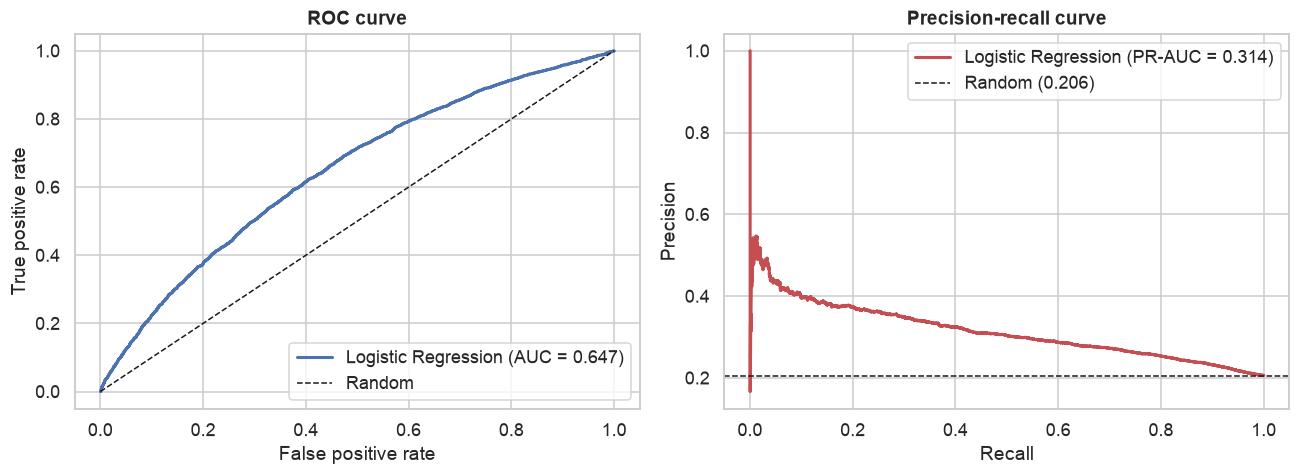

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[0].plot(fpr, tpr, lw=2, label=f"Logistic Regression (AUC = {auc_roc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_val, val_proba)
axes[1].plot(rec, prec, lw=2, color="#C44E52", label=f"Logistic Regression (PR-AUC = {pr_auc:.3f})")
axes[1].axhline(y_val.mean(), ls="--", c="k", lw=1, label=f"Random ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve"); axes[1].legend()

fig.tight_layout(); save(fig, "10_baseline_curves"); plt.show()

## 5. Which features drive the prediction?

Logistic regression coefficients are in log-odds. Exponentiating gives an **odds ratio**: how the odds of lapsing change per one standard deviation increase in that feature (for numeric features).

Above 1 means more likely to lapse. Below 1 means less likely.

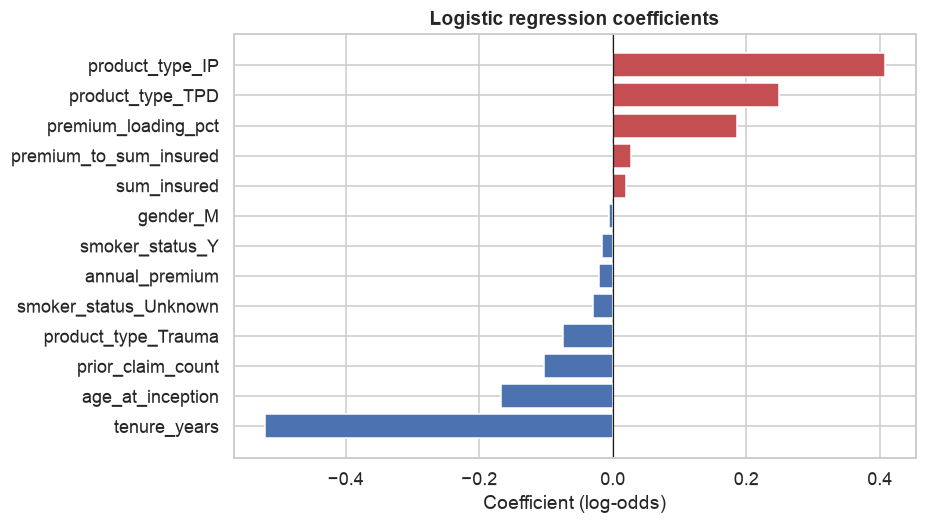

,feature,coefficient,odds_ratio
6,tenure_years,-0.522,0.594
10,product_type_IP,0.407,1.502
11,product_type_TPD,0.248,1.282
3,premium_loading_pct,0.186,1.205
0,age_at_inception,-0.167,0.846
4,prior_claim_count,-0.102,0.903
12,product_type_Trauma,-0.074,0.928
8,smoker_status_Unknown,-0.030,0.970
5,premium_to_sum_insured,0.027,1.027
2,annual_premium,-0.020,0.980


In [27]:
feat_names = baseline.named_steps["prep"].get_feature_names_out()
coefs = baseline.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({"feature": [f.split("__", 1)[1] for f in feat_names],
                         "coefficient": coefs})
           .assign(odds_ratio=lambda d: np.exp(d.coefficient))
           .sort_values("coefficient"))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coef_df.coefficient]
ax.barh(coef_df.feature, coef_df.coefficient, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Logistic regression coefficients")
save(fig, "11_baseline_coefficients"); plt.show()

coef_df.sort_values("coefficient", key=abs, ascending=False).round(3)

## 6. Choosing a decision threshold

A model outputs a probability. Turning it into a yes/no decision needs a cut-off, and 0.5 is just a default, not a law.

The right threshold depends on the business cost. Here, a false positive means a retention call to someone who was staying anyway — cheap. A false negative means losing a customer you could have kept — expensive. So recall matters more than precision, and the threshold should sit below 0.5.

**F1** balances the two, so it's a reasonable neutral starting point.

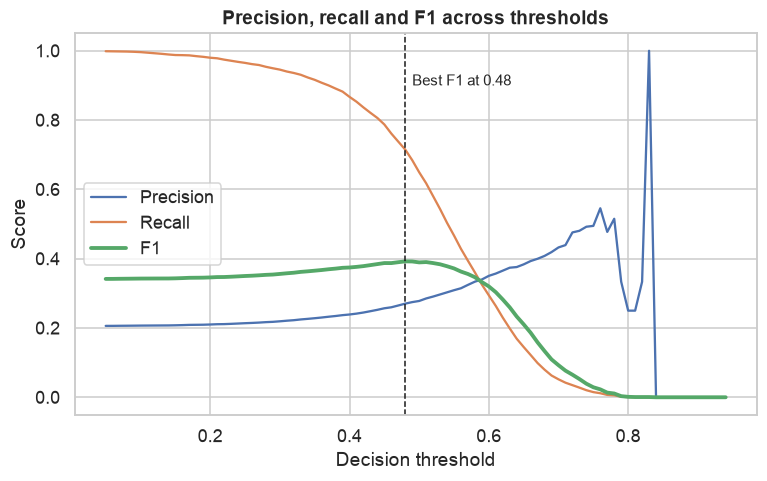

Best threshold 0.48  precision 0.270  recall 0.715  F1 0.392


In [28]:
thresholds = np.arange(0.05, 0.95, 0.01)
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    rows.append({"threshold": t, "precision": precision, "recall": recall, "f1": f1})

thr_df = pd.DataFrame(rows)
best = thr_df.loc[thr_df.f1.idxmax()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thr_df.threshold, thr_df.precision, label="Precision")
ax.plot(thr_df.threshold, thr_df.recall, label="Recall")
ax.plot(thr_df.threshold, thr_df.f1, label="F1", lw=2.5)
ax.axvline(best.threshold, ls="--", c="k", lw=1)
ax.text(best.threshold + 0.01, 0.9, f"Best F1 at {best.threshold:.2f}", fontsize=10)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Precision, recall and F1 across thresholds")
ax.legend()
save(fig, "12_threshold_tuning"); plt.show()

print(f"Best threshold {best.threshold:.2f}  precision {best.precision:.3f}  "
      f"recall {best.recall:.3f}  F1 {best.f1:.3f}")

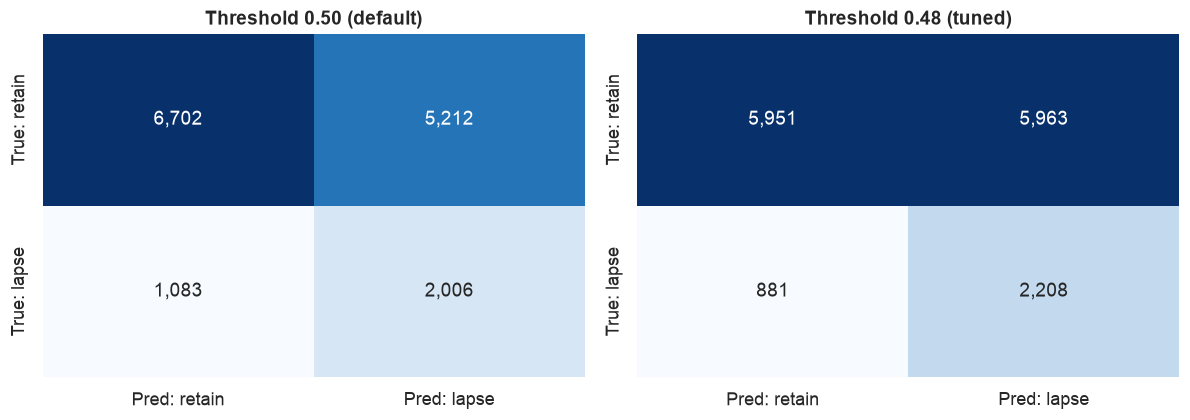

              precision    recall  f1-score   support

    Retained      0.871     0.499     0.635     11914
      Lapsed      0.270     0.715     0.392      3089

    accuracy                          0.544     15003
   macro avg      0.571     0.607     0.514     15003
weighted avg      0.747     0.544     0.585     15003



In [29]:
pred_default = (val_proba >= 0.5).astype(int)
pred_tuned = (val_proba >= best.threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in [(axes[0], pred_default, "Threshold 0.50 (default)"),
                        (axes[1], pred_tuned, f"Threshold {best.threshold:.2f} (tuned)")]:
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: retain", "Pred: lapse"],
                yticklabels=["True: retain", "True: lapse"])
    ax.set_title(title)
fig.tight_layout(); save(fig, "13_baseline_confusion"); plt.show()

print(classification_report(y_val, pred_tuned, target_names=["Retained", "Lapsed"], digits=3))

## 7. Save results

Metrics are saved to JSON so the next notebook can compare against them without re-running anything.

In [30]:
results = {
    "model": "LogisticRegression (class_weight=balanced)",
    "val_auc_roc": round(float(auc_roc), 4),
    "val_pr_auc": round(float(pr_auc), 4),
    "best_threshold": round(float(best.threshold), 2),
    "val_precision_at_best": round(float(best.precision), 4),
    "val_recall_at_best": round(float(best.recall), 4),
    "val_f1_at_best": round(float(best.f1), 4),
}
with open(RESULTS / "baseline_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "model": "LogisticRegression (class_weight=balanced)",
  "val_auc_roc": 0.6471,
  "val_pr_auc": 0.3138,
  "best_threshold": 0.48,
  "val_precision_at_best": 0.2702,
  "val_recall_at_best": 0.7148,
  "val_f1_at_best": 0.3922
}


## Summary

| | |
|---|---|
| Model | Logistic regression, balanced class weights |
| Validation AUC-ROC | see above |
| Validation PR-AUC | compare against the ~0.083 random baseline |
| Threshold | tuned on validation, not left at 0.5 |

The coefficients line up with the EDA: tenure is strongly protective, premium loading pushes risk up, and income protection lapses more than other products. A model whose coefficients contradicted the EDA would be a warning sign.

**Next:** `03_xgboost_model.ipynb` — does a non-linear model actually beat this?